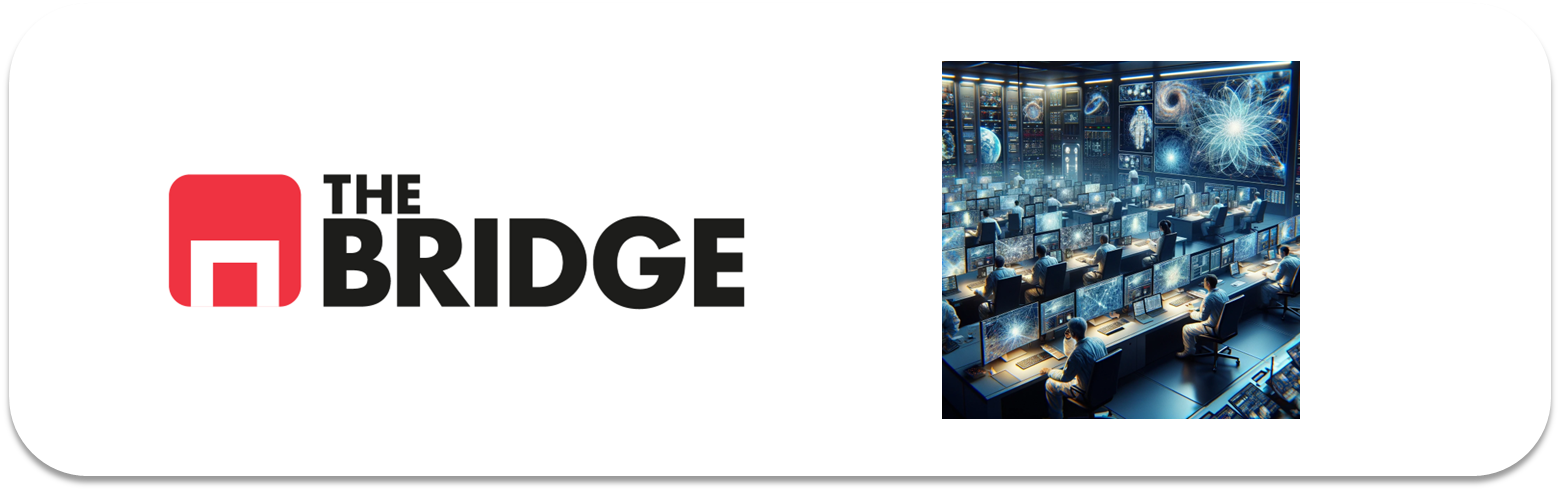

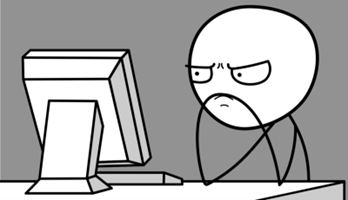

Para ejercitarte y afianzar lo aprendido sobre **Redes Convolucionales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
# filter warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

## El problema de "Negocio"
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test como `seg_train.zip` y `seg_test.zip` (o bien en el botón de download).  

NOTA: Son archivos bastante grandes (386MB en total). Por supuesto, no es necesario que tengas que mantenerlos en tu ordenador una vez realizado el ejercicio, bórralos si es el caso.




### Ejercicio 1

Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones). Para ello:

1. Descarga las imagenes del repositorio de Kaggle en el directorio que vayas a emplear para el ejercicio.
2. Descomprime los datos (son ficheros de imágenes) de forma que tengas dos subdirectorios seg_train y seg_test en el que estén ya colgando directamente los directorios de cada clase de paisajes. Si descargaste seg_pred, puedes eliminarlo.
3. Crea unas variables como las siguientes (ajustándolas a tu caso/rutas particulares):

```python
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
```
4. Utiliza la siguiente función para crear los X_train, y_train y X_test e y_test:

```python
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)
```


*Pues copiamos lo que nos dicen y lo aplicamos a los dos directorios para tener las X y las y*

In [2]:
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

In [3]:
import os
import cv2
from cv2 import imread

def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)

In [4]:
X_train,y_train = read_data(TRAIN_PATH)

In [5]:
X_test,y_test = read_data(TEST_PATH)

In [6]:
X_train.shape, y_train.shape

((14034, 32, 32, 3), (14034,))

### Ejercicio 2

Haz la visualización del dataset: comprueba cuantos datos tienes, que forma, investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


In [7]:
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 14034
Test samples: 3000


In [8]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14034, 32, 32, 3)
y_train shape: (14034,)
X_test shape: (3000, 32, 32, 3)
y_test shape: (3000,)


In [9]:
print("Unique labels:", np.unique(y_train))

Unique labels: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


In [10]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(label, ":", count)

buildings : 2191
forest : 2271
glacier : 2404
mountain : 2512
sea : 2274
street : 2382


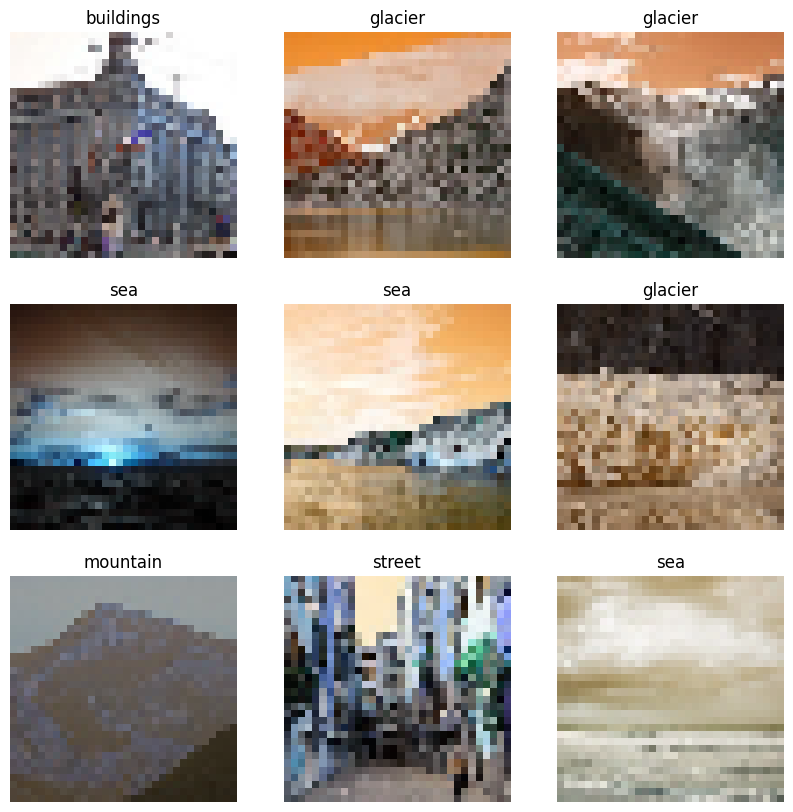

In [11]:
import random

plt.figure(figsize=(10,10))

for i in range(9):
    
    index = random.randint(0, len(X_train))
    
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[index])
    plt.title(y_train[index])
    plt.axis("off")

plt.show()

In [12]:
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: 0
Max pixel value: 255


### Ejercicio 3

Ahora haz un pequeño miniEda y normaliza las features



In [13]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(label, ":", count)

buildings : 2191
forest : 2271
glacier : 2404
mountain : 2512
sea : 2274
street : 2382


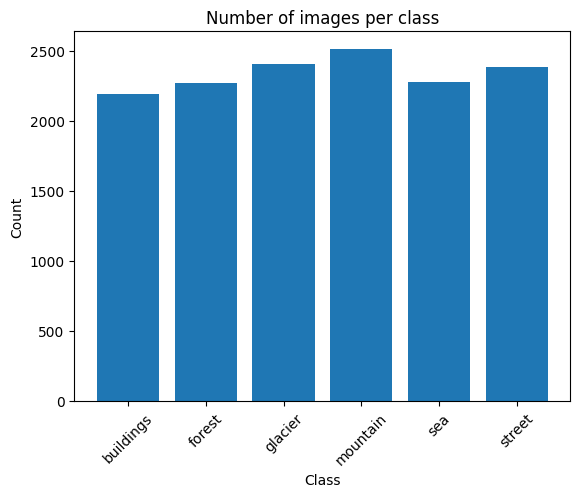

In [14]:
import matplotlib.pyplot as plt

plt.bar(unique, counts)
plt.title("Number of images per class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Use label encoding to change labels into numeric values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [16]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [17]:
X_train.min(),X_train.max()

(np.float64(0.0), np.float64(1.0))

### Ejercicio 4

Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada. Como guía, copia o parte de la arquitectura del workout (un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer)


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    layers.Dense(6, activation='softmax')
])

### Ejercicio 5

Escoge el resto de hiperparámetros (optimizador, learning_rate, función de pérdida, métrica,...) y compila el modelo. Muestra un resumen del mismo

In [19]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [20]:
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,302 (653.52 KB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 6

Entrena el modelo reservando un 20% de los datos del entrenamiento para validar y con los callbacks que creas necesarios. NOTA: Ojo, tendrás que preparar un poco los X,y antes.



In [22]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [23]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5718 - loss: 1.0945 - val_accuracy: 0.6662 - val_loss: 0.8786 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6777 - loss: 0.8571 - val_accuracy: 0.7022 - val_loss: 0.8180 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7264 - loss: 0.7452 - val_accuracy: 0.7463 - val_loss: 0.7152 - learning_rate: 0.0010
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7517 - loss: 0.6741 - val_accuracy: 0.7442 - val_loss: 0.7116 - learning_rate: 0.0010
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7803 - loss: 0.6104 - val_accuracy: 0.7150 - val_loss: 0.7887 - learning_rate: 0.0010
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7983 - loss: 0.5632 - val_accuracy: 0.7442 - val_loss: 0.6894 - learning_rate: 0.0010
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8110 - loss: 0.5240 - 


### Ejercicio 7

Representa el objeto history y comenta la evolución de tu entrenamiento.



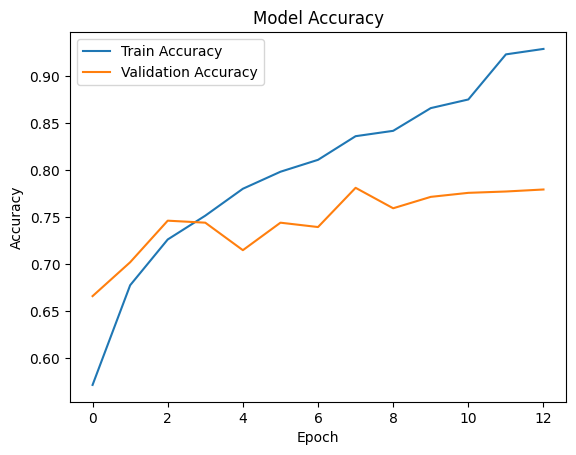

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


### Ejercicio 8

Evalua el modelo con los datos de test, además muestra el report de clasificación y la matriz de confusión.



In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7843 - loss: 0.6204
Test loss: 0.6204249262809753
Test accuracy: 0.784333348274231


In [29]:
y_pred_probs = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [30]:
y_pred = [np.argmax(prediction) for prediction in  model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.79      0.73       437
           1       0.89      0.91      0.90       474
           2       0.77      0.75      0.76       553
           3       0.80      0.73      0.77       525
           4       0.74      0.79      0.76       510
           5       0.83      0.75      0.79       501

    accuracy                           0.78      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.78      0.78      3000




### Ejercicio 9 

Representa algunos de los paisajes donde el modelo comete errores y muestra la confianza que tenía en ellos.


In [28]:
incorrect = np.where(y_pred != y_test)[0]

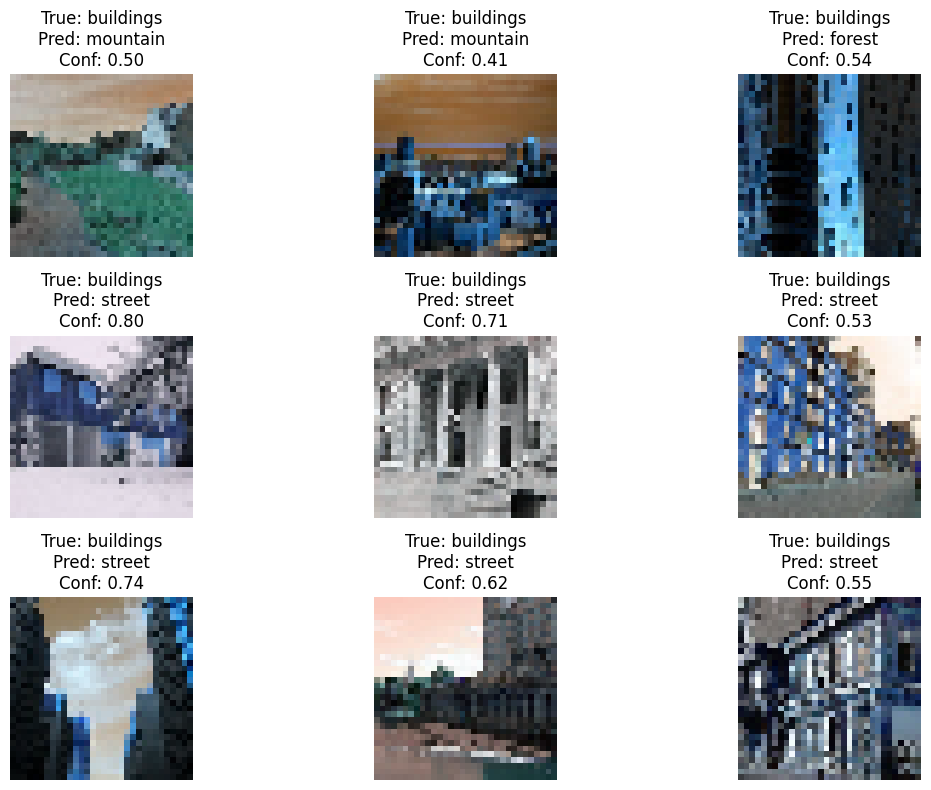

In [32]:
plt.figure(figsize=(12,8))

for i, idx in enumerate(incorrect[:9]):

    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx])
    
    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]
    
    confidence = np.max(y_pred_probs[idx])

    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Ejercicio EXTRA: 

Aumenta la resolución y repite el ejercicio con la misma topología de red

In [35]:
X_train, y_train = read_data(TRAIN_PATH, reshape_dim=(64,64))

In [36]:
X_test, y_test = read_data(TEST_PATH, reshape_dim=(64,64))

In [37]:
X_train.shape

(14034, 64, 64, 3)

In [42]:
# normalise images

X_train = X_train/255
X_test = X_test/255

In [46]:
X_train.min(), X_train.max()

(np.float64(0.0), np.float64(1.0))

In [47]:
# Label encoding

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [48]:
# Shuffle dataset

X_train, y_train = shuffle(X_train,y_train,random_state=42)

In [59]:
from keras import Sequential
from keras.layers import Dense,Flatten,MaxPooling2D

model = keras.Sequential([
    layers.Conv2D(32,(3,3), activation="relu",input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),   # new layer
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.4),

    layers.Dense(6, activation = "softmax")
])

In [60]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer = optimizer,
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [61]:
history =  model.fit(
    X_train,
    y_train,
    epochs = 30,
    batch_size = 32,
    validation_split = 0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5076 - loss: 1.2167 - val_accuracy: 0.6213 - val_loss: 0.9369 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6291 - loss: 0.9727 - val_accuracy: 0.6983 - val_loss: 0.7959 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6904 - loss: 0.8404 - val_accuracy: 0.7317 - val_loss: 0.7251 - learning_rate: 0.0010
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7505 - loss: 0.6991 - val_accuracy: 0.7656 - val_loss: 0.6405 - learning_rate: 3.0000e-04
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7731 - loss: 0.6440 - val_accuracy: 0.7816 - val_loss: 0.6158 - learning_rate: 3.0000e-04
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7852 - loss: 0.6097 - val_accuracy: 0.7624 - val_loss: 0.6504 - learning_rate: 3.0000e-04
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.794

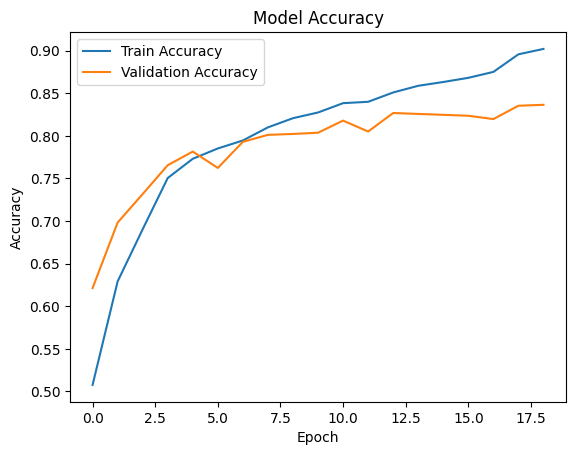

In [62]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [63]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8223 - loss: 0.4884
Test loss: 0.4884055256843567
Test accuracy: 0.8223333358764648


In [64]:
y_pred_probs = model.predict(X_test)

y_pred = [np.argmax(prediction) for prediction in  model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [65]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       437
           1       0.92      0.97      0.95       474
           2       0.79      0.75      0.77       553
           3       0.77      0.78      0.77       525
           4       0.77      0.83      0.80       510
           5       0.87      0.82      0.85       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



In [66]:
incorrect = np.where(y_pred != y_test)[0]

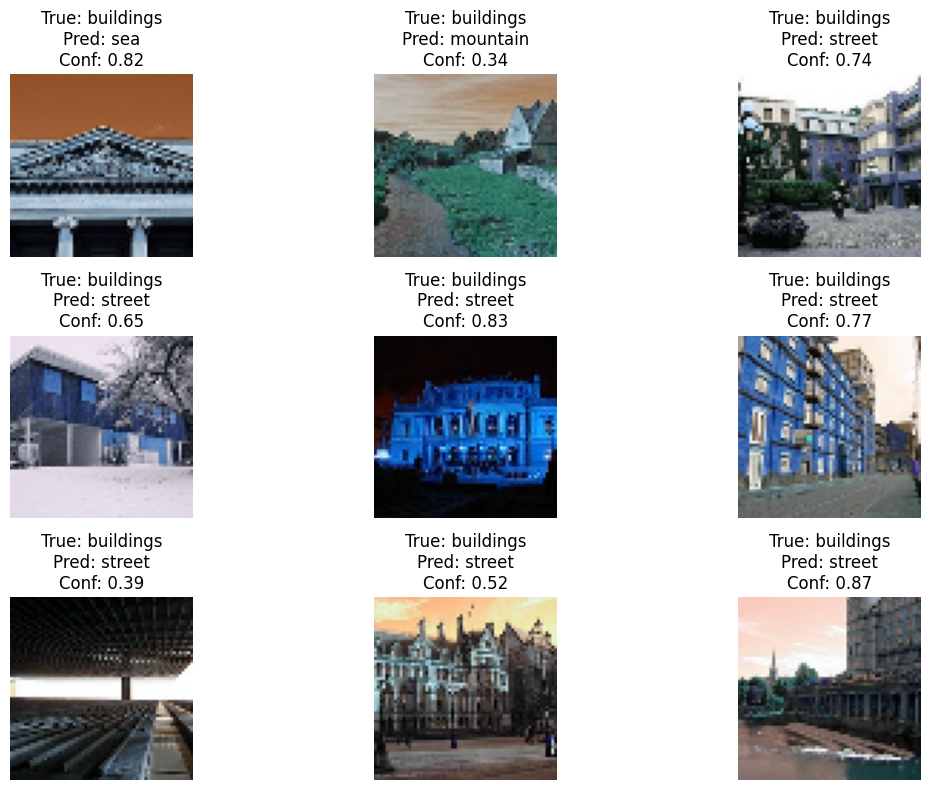

In [67]:
plt.figure(figsize=(12,8))

for i, idx in enumerate(incorrect[:9]):

    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx])
    
    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]
    
    confidence = np.max(y_pred_probs[idx])

    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()